# 2.nivelSegmento · 2. Modelización RF (nivel de ventana + agregación a sesión)

Random Forest **regresor del PHQ-8 entrenado sobre ventanas** (enfoque híbrido: acústicas por
ventana + pausas de sesión difundidas). Dos piezas críticas frente al notebook de sesión:

1. **Partición por sesión (`StratifiedGroupKFold`, `groups=participant_id`).** Todas las
   ventanas de una sesión van juntas al mismo fold. Evita la fuga que habría si ventanas de
   la misma sesión cayeran en train y validación a la vez.
2. **Agregación ventana → sesión.** El modelo predice por ventana, pero la **métrica final se
   calcula a nivel de sesión** (media de las predicciones de sus ventanas). Es la unidad
   clínica y la que hace la comparación justa con el modelo de sesión (AUC 0.743).

La búsqueda de hiperparámetros optimiza el RMSE **por ventana** (proxy) con `GroupKFold`; la
evaluación honesta (CV y test) se hace **agregada a sesión**.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint

from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_auc_score, f1_score, accuracy_score,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
import shap

import warnings
warnings.filterwarnings('ignore')

c:\Users\tblxa\Desktop\Master\UNIR_IA_TFE\unir_tfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
##################################################
####           Constantes del modelo          ####
##################################################
from pathlib import Path
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
path_df = PROJECT_DIR + '/output/df_segment_features_vf.csv'

PHQ_THRESHOLD = 10
RANDOM_STATE  = 42
N_ITER_SEARCH = 40
N_CV_FOLDS    = 5
K_FEATURES    = 20

# Columnas que NO son features (identificadores, target, partición, índice de ventana)
NON_FEATURE = ['participant_id', 'phq8_binary', 'phq8_score', 'split', 'window_idx']
TARGET = 'phq8_score'
GROUP  = 'participant_id'

ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')

## 1. Carga y partición por sesión

In [3]:
df = pd.read_csv(path_df)

COLS_FEATURES = [c for c in df.columns if c not in NON_FEATURE]   # gender + 14 pausas + 45 acústicas
ACOUSTIC_COLS = [c for c in COLS_FEATURES if c.startswith(ACOUSTIC_PREFIXES)]

# Tabla de etiquetas A NIVEL DE SESIÓN (una fila por participante)
sess = df.drop_duplicates(GROUP).set_index(GROUP)
sess_bin = (sess[TARGET] >= PHQ_THRESHOLD).astype(int)

# Partición por sesión (heredada del corpus, difundida a las ventanas)
df_td = df[df['split'].isin(['train', 'dev'])].reset_index(drop=True)
df_te = df[df['split'] == 'test'].reset_index(drop=True)

X_td, y_td, g_td = df_td[COLS_FEATURES], df_td[TARGET], df_td[GROUP]
X_te, y_te, g_te = df_te[COLS_FEATURES], df_te[TARGET], df_te[GROUP]

print(f"Ventanas  train+dev: {len(X_td):>6}  |  sesiones: {g_td.nunique()}")
print(f"Ventanas  test     : {len(X_te):>6}  |  sesiones: {g_te.nunique()}")
print(f"Deprimidos (sesión): train+dev {int(sess_bin.loc[g_td.unique()].sum())}/{g_td.nunique()}  "
      f"| test {int(sess_bin.loc[g_te.unique()].sum())}/{g_te.nunique()}")
print(f"Features: {len(COLS_FEATURES)}  ({len(ACOUSTIC_COLS)} acústicas + {len(COLS_FEATURES)-len(ACOUSTIC_COLS)} pausas/gender)")

Ventanas  train+dev:  13794  |  sesiones: 140
Ventanas  test     :   5215  |  sesiones: 46
Deprimidos (sesión): train+dev 43/140  | test 14/46
Features: 60  (45 acústicas + 15 pausas/gender)


In [4]:
# CV estratificada POR GRUPO: estratifica por depresión y mantiene juntas las ventanas de cada sesión
y_td_bin = (y_td >= PHQ_THRESHOLD).astype(int)
sgkf = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(sgkf.split(X_td, y_td_bin, groups=g_td))

# Comprobación anti-fuga: ninguna sesión aparece en train y val del mismo fold
for k, (tr, va) in enumerate(cv_splits):
    solap = set(g_td.iloc[tr]) & set(g_td.iloc[va])
    assert len(solap) == 0, f"FUGA en fold {k}: {solap}"
print("OK — sin solape de sesiones entre train y val en ningún fold")
print(f"Sesiones por fold (val): {[g_td.iloc[va].nunique() for _, va in cv_splits]}")

OK — sin solape de sesiones entre train y val en ningún fold
Sesiones por fold (val): [28, 28, 28, 28, 28]


## 2. Pipeline y utilidades de agregación

In [5]:
class GenderZScoreScaler(BaseEstimator, TransformerMixin):
    """Z-score de las columnas acústicas DENTRO de cada grupo de sexo (sin fuga en CV)."""
    def __init__(self, cols, gender_col='gender'):
        self.cols = cols; self.gender_col = gender_col
    def fit(self, X, y=None):
        self.stats_ = {}
        for g, sub in X.groupby(self.gender_col):
            mu = sub[self.cols].mean(); sd = sub[self.cols].std(ddof=0).replace(0, 1.0)
            self.stats_[g] = (mu, sd)
        self.global_ = (X[self.cols].mean(), X[self.cols].std(ddof=0).replace(0, 1.0))
        return self
    def transform(self, X):
        X = X.copy()
        for g, idx in X.groupby(self.gender_col).groups.items():
            mu, sd = self.stats_.get(g, self.global_)
            X.loc[idx, self.cols] = (X.loc[idx, self.cols] - mu) / sd
        return X

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X.drop(columns=[c for c in self.cols if c in X.columns])

def build_model(**rf_params):
    """Mismo preprocesado que a nivel de sesión + imputación (robustez ante NaN de ventana)."""
    return Pipeline([
        ('gender',     GenderZScoreScaler(ACOUSTIC_COLS)),
        ('dropgender', DropColumns(['gender'])),
        ('imputer',    SimpleImputer(strategy='median')),
        ('scaler',     StandardScaler()),
        ('select',     SelectKBest(f_regression, k=K_FEATURES)),
        ('rf',         RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_params)),
    ])

def agg_to_session(part_ids, y_pred_win):
    """Media de las predicciones de ventana por sesión -> Series indexada por participant_id."""
    return pd.Series(np.asarray(y_pred_win), index=np.asarray(part_ids)).groupby(level=0).mean()

## 3. Búsqueda de hiperparámetros (RMSE por ventana, GroupKFold)

In [6]:
param_dist = {
    'rf__n_estimators':      randint(100, 500),
    'rf__max_depth':         [None, 8, 10, 12, 15, 20],
    'rf__min_samples_split': randint(2, 40),
    'rf__min_samples_leaf':  randint(1, 20),
    'rf__max_features':      ['sqrt', 'log2', 0.3, 0.5],
}

search = RandomizedSearchCV(
    estimator=build_model(),
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring='neg_root_mean_squared_error',
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_td, y_td)

print("\nMejores hiperparámetros:")
for k, v in search.best_params_.items():
    print(f"  {k:<26}: {v}")
print(f"\nMejor RMSE por ventana (CV): {-search.best_score_:.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Mejores hiperparámetros:
  rf__max_depth             : 8
  rf__max_features          : log2
  rf__min_samples_leaf      : 13
  rf__min_samples_split     : 33
  rf__n_estimators          : 330

Mejor RMSE por ventana (CV): 5.516


## 4. Evaluación en CV **a nivel de sesión** (métrica honesta)
Para cada fold: se entrena con las ventanas de train, se predicen las de validación y se
**agregan a sesión** (media). Se obtiene una predicción out-of-fold por sesión, con la que se
calcula el AUC y se ajusta el umbral (F1).

In [7]:
oof = {}
for tr, va in cv_splits:
    m = clone(search.best_estimator_)
    m.fit(X_td.iloc[tr], y_td.iloc[tr])
    p_va = m.predict(X_td.iloc[va])
    oof.update(agg_to_session(g_td.iloc[va], p_va).to_dict())

oof_pred = pd.Series(oof)
oof_y    = sess_bin.loc[oof_pred.index]

auc_cv = roc_auc_score(oof_y, oof_pred)
# Umbral óptimo F1 sobre las predicciones OOF de sesión
ths = np.linspace(oof_pred.min(), oof_pred.max(), 200)
f1s = [f1_score(oof_y, (oof_pred >= t).astype(int), zero_division=0) for t in ths]
best_thr = ths[int(np.argmax(f1s))]

print(f"── CV agregada a sesión ({oof_pred.shape[0]} sesiones) ──")
print(f"AUC (OOF, sesión)          : {auc_cv:.3f}")
print(f"Umbral óptimo F1 (PHQ-8)   : {best_thr:.2f}")
print(f"F1 deprimido (OOF, umbral) : {max(f1s):.3f}")

── CV agregada a sesión (140 sesiones) ──
AUC (OOF, sesión)          : 0.655
Umbral óptimo F1 (PHQ-8)   : 7.25
F1 deprimido (OOF, umbral) : 0.529


## 5. Evaluación final en TEST (agregada a sesión)

In [8]:
rf_final = clone(search.best_estimator_)
rf_final.fit(X_td, y_td)

p_te_win  = rf_final.predict(X_te)
pred_sess = agg_to_session(g_te, p_te_win)      # PHQ-8 predicho por sesión
y_sess    = sess_bin.loc[pred_sess.index]

auc = roc_auc_score(y_sess, pred_sess)

def clf_at(thr):
    yhat = (pred_sess >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_sess, yhat, average='binary', zero_division=0)
    return p, r, f, accuracy_score(y_sess, yhat)

# Bootstrap IC95 del AUC a nivel de sesión
rng = np.random.RandomState(RANDOM_STATE); ys = y_sess.values; ps = pred_sess.values
boot = []
for _ in range(2000):
    s = rng.randint(0, len(ys), len(ys))
    if len(np.unique(ys[s])) < 2: continue
    boot.append(roc_auc_score(ys[s], ps[s]))
lo, hi = np.percentile(boot, [2.5, 97.5])

print("── TEST (nivel sesión) ──────────────────────────")
print(f"AUC                : {auc:.3f}   IC95% [{lo:.2f}, {hi:.2f}]")
for name, thr in [('nominal (>=10)', PHQ_THRESHOLD), (f'óptimo F1 ({best_thr:.2f})', best_thr)]:
    p, r, f, a = clf_at(thr)
    print(f"[{name:<18}]  Prec {p:.3f}  Rec {r:.3f}  F1 {f:.3f}  Acc {a:.3f}")
print(f"\nReferencia nivel-sesión (notebook 3.1 RF vf): AUC 0.743")

── TEST (nivel sesión) ──────────────────────────
AUC                : 0.728   IC95% [0.57, 0.87]
[nominal (>=10)    ]  Prec 0.667  Rec 0.286  F1 0.400  Acc 0.739
[óptimo F1 (7.25)  ]  Prec 0.429  Rec 0.643  F1 0.514  Acc 0.630

Referencia nivel-sesión (notebook 3.1 RF vf): AUC 0.743


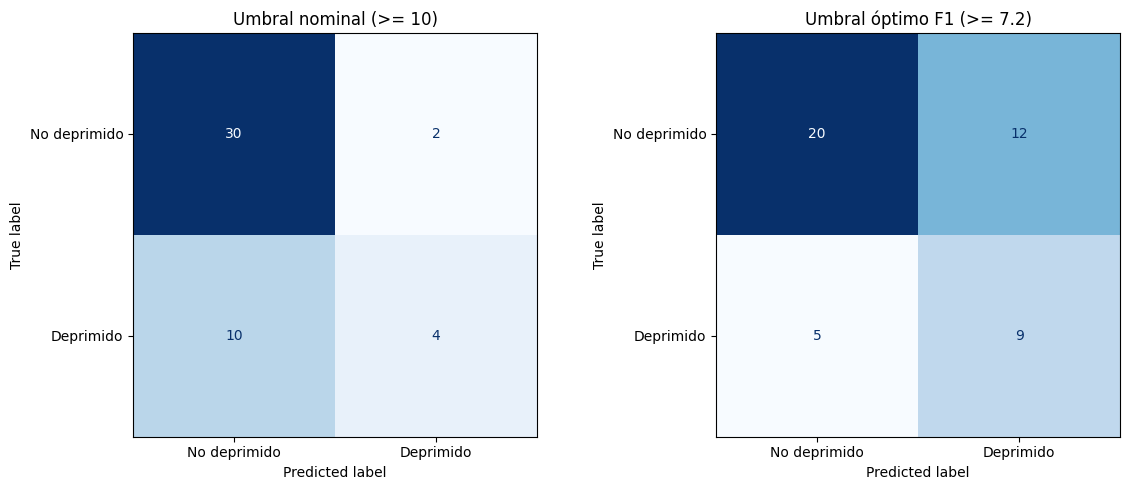

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, thr, title in [(axes[0], PHQ_THRESHOLD, f'Umbral nominal (>= {PHQ_THRESHOLD})'),
                       (axes[1], best_thr, f'Umbral óptimo F1 (>= {best_thr:.1f})')]:
    ConfusionMatrixDisplay.from_predictions(
        y_sess, (pred_sess >= thr).astype(int),
        display_labels=['No deprimido', 'Deprimido'], colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 6. Interpretabilidad — SHAP (nivel de ventana)
SHAP sobre una muestra de ventanas de test (por coste). Al haber miles de ventanas, el ranking
es mucho más estable que a nivel de sesión. Incluye acústicas por ventana y pausas difundidas.

Features seleccionadas (20):
  9 acústicas + 11 pausas/turnos


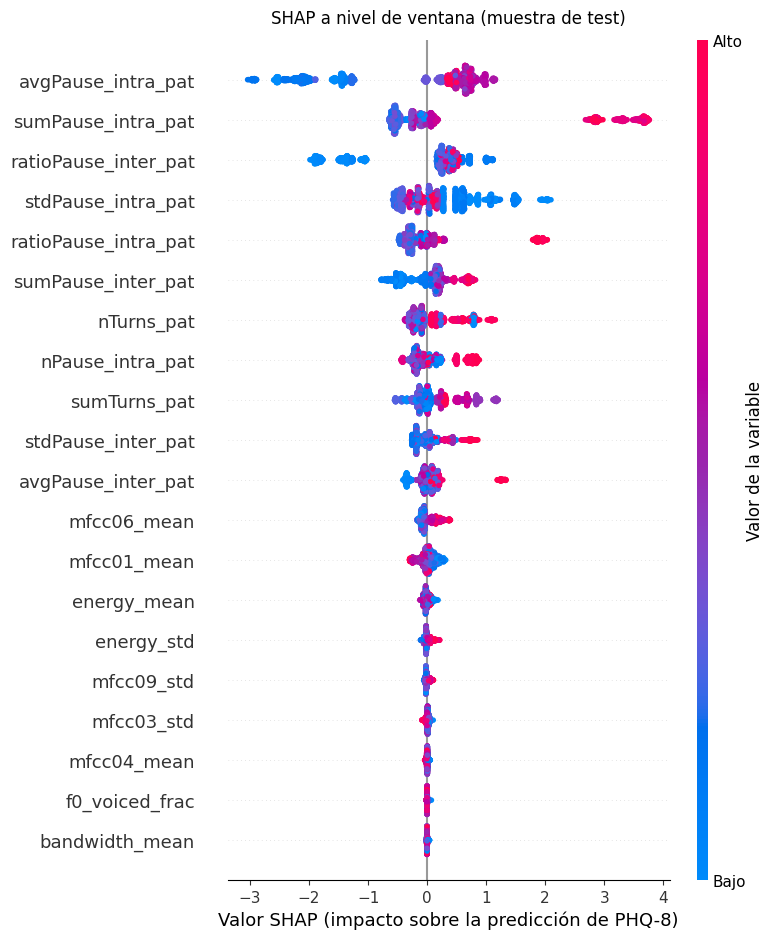

In [10]:
gender_f = rf_final.named_steps['gender']
drop_f   = rf_final.named_steps['dropgender']
imp_f    = rf_final.named_steps['imputer']
scaler_f = rf_final.named_steps['scaler']
sel_f    = rf_final.named_steps['select']
rf_f     = rf_final.named_steps['rf']

cols_after_drop = [c for c in COLS_FEATURES if c != 'gender']
feat_names = [c for c, keep in zip(cols_after_drop, sel_f.get_support()) if keep]

# muestra de ventanas de test para el SHAP
Xs = X_te.sample(n=min(2500, len(X_te)), random_state=RANDOM_STATE)
Xt = sel_f.transform(scaler_f.transform(imp_f.transform(drop_f.transform(gender_f.transform(Xs)))))
Xt_df = pd.DataFrame(Xt, columns=feat_names)

explainer   = shap.TreeExplainer(rf_f)
shap_values = explainer.shap_values(Xt_df)

print(f"Features seleccionadas ({len(feat_names)}):")
n_ac = sum(1 for f in feat_names if f in ACOUSTIC_COLS)
print(f"  {n_ac} acústicas + {len(feat_names)-n_ac} pausas/turnos")

plt.figure()
shap.summary_plot(shap_values, Xt_df, plot_type='dot', max_display=20, show=False)
# rotulos en castellano (la libreria SHAP los genera en ingles)
_fig = plt.gcf()
plt.gca().set_xlabel('Valor SHAP (impacto sobre la predicción de PHQ-8)')
for _a in _fig.axes[1:]:
    if _a.get_ylabel() == 'Feature value':
        _a.set_ylabel('Valor de la variable')
        if len(_a.get_yticklabels()) == 2:
            _a.set_yticklabels(['Bajo', 'Alto'])
plt.title('SHAP a nivel de ventana (muestra de test)', pad=12)
plt.tight_layout(); plt.show()

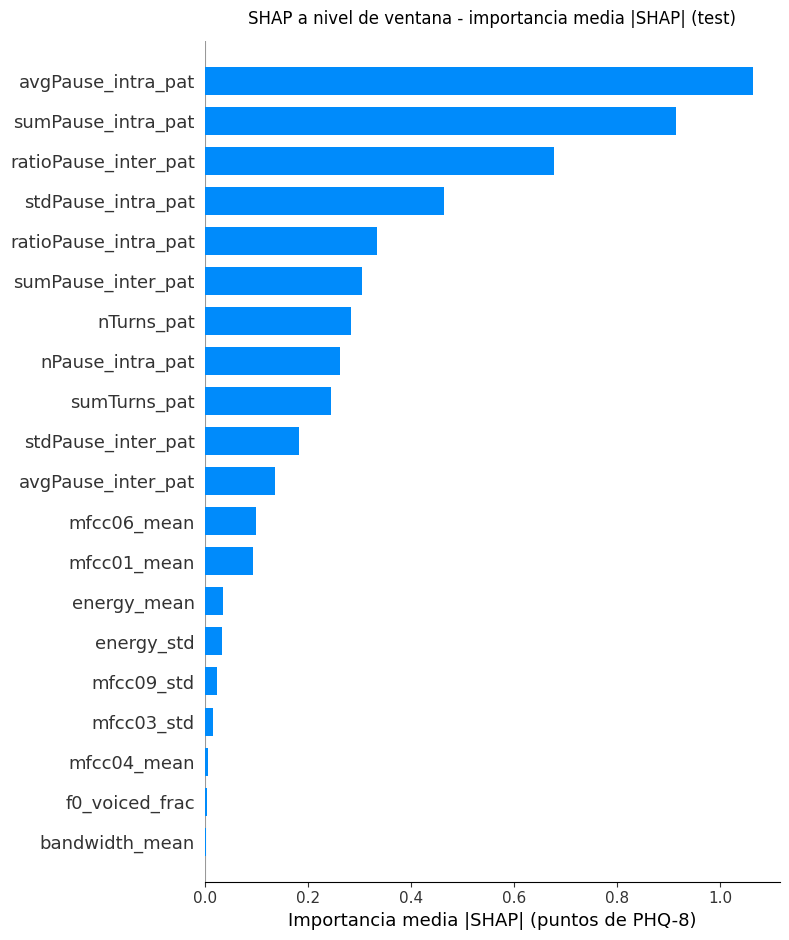

In [11]:
plt.figure()
shap.summary_plot(shap_values, Xt_df, plot_type='bar', max_display=20, show=False)
# rotulo en castellano (la libreria SHAP lo genera en ingles)
plt.gca().set_xlabel('Importancia media |SHAP| (puntos de PHQ-8)')
plt.title('SHAP a nivel de ventana - importancia media |SHAP| (test)', pad=12)
plt.tight_layout(); plt.show()